<a href="https://colab.research.google.com/github/akashpai200511112-art/OIBSIP/blob/main/EDARetailSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
df = pd.read_csv("/retail_sales.csv.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


# EDA on Retail Sales Data

## Oasis Infobyte Data Analytics Internship

**Name:** Akash Pai  
**Track:** Data Analytics  
**Task:** Exploratory Data Analysis on Retail Sales Data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 1000
Number of columns: 9

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [13]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0


In [14]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [15]:
print(df.columns.tolist())

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


In [16]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year

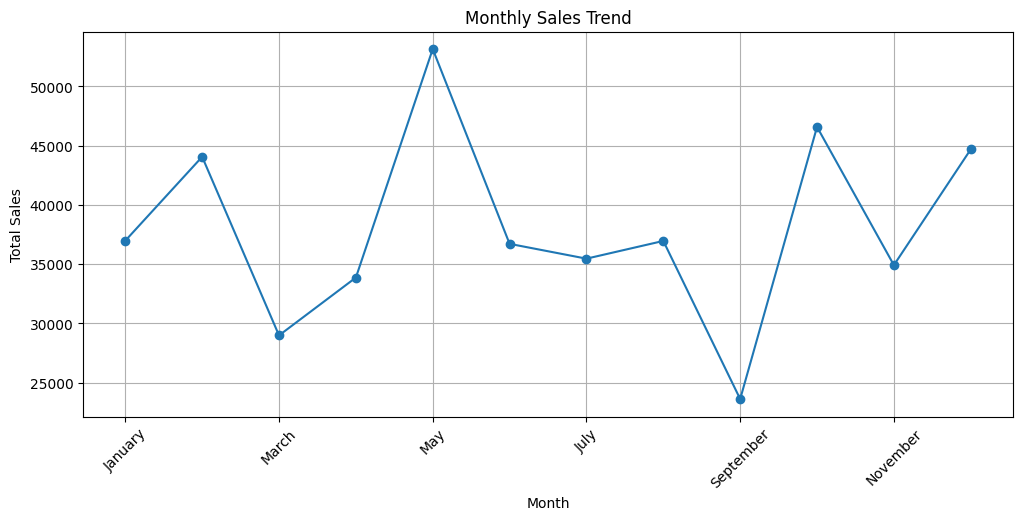

In [17]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

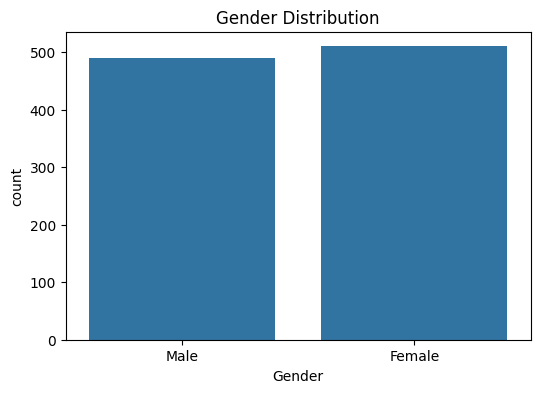

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.show()

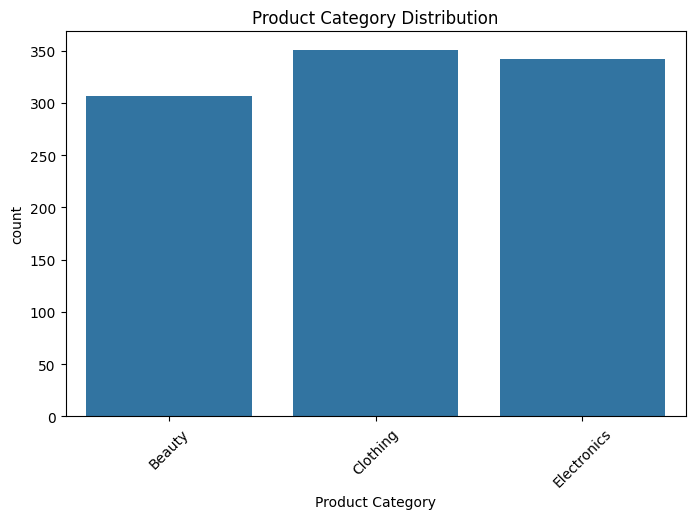

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Product Category")
plt.title("Product Category Distribution")
plt.xticks(rotation=45)
plt.show()

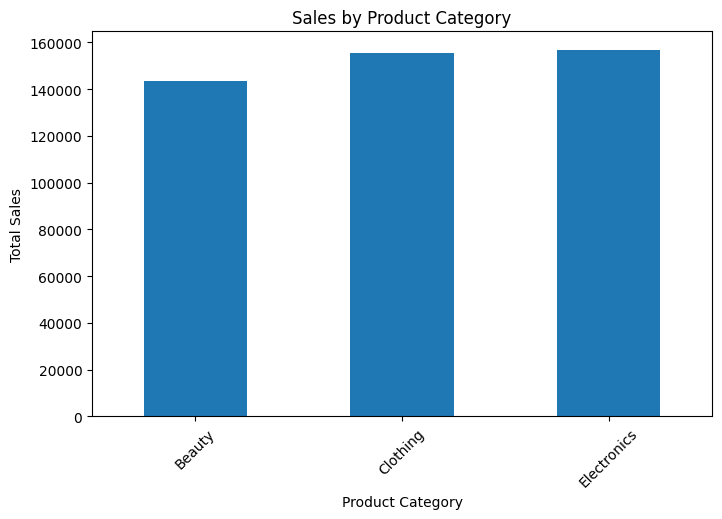

In [20]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

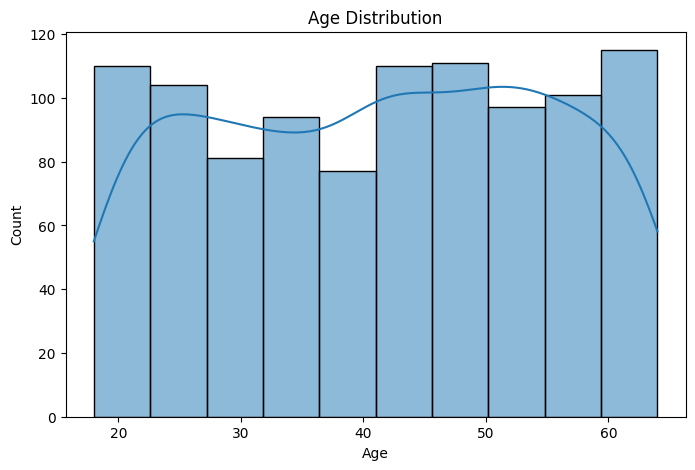

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=10, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

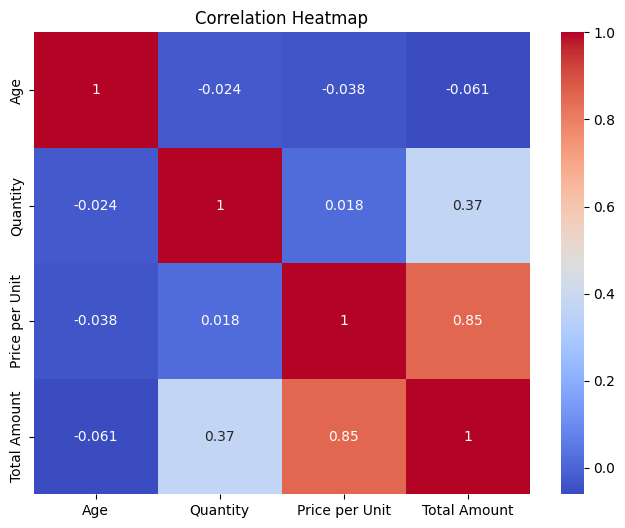

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Age","Quantity","Price per Unit","Total Amount"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [23]:
top_sales = df.sort_values(by="Total Amount", ascending=False)

top_sales.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year
945,946,2023-05-08,CUST946,Male,62,Electronics,4,500,2000,May,2023
71,72,2023-05-23,CUST072,Female,20,Electronics,4,500,2000,May,2023
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000,January,2023
576,577,2023-02-13,CUST577,Male,21,Beauty,4,500,2000,February,2023
571,572,2023-04-20,CUST572,Male,31,Clothing,4,500,2000,April,2023
268,269,2023-02-01,CUST269,Male,25,Clothing,4,500,2000,February,2023
502,503,2023-10-25,CUST503,Male,45,Beauty,4,500,2000,October,2023
926,927,2023-06-24,CUST927,Male,43,Electronics,4,500,2000,June,2023
252,253,2023-08-31,CUST253,Female,53,Clothing,4,500,2000,August,2023
546,547,2023-03-07,CUST547,Male,63,Clothing,4,500,2000,March,2023


# Business Insights

- Monthly sales trends help identify peak and low sales periods.
- The gender distribution provides insights into customer demographics.
- Product category analysis highlights the best-performing categories.
- Age distribution helps understand the primary customer age groups.
- The correlation heatmap shows relationships between numerical variables.
- These insights can help improve inventory management, marketing strategies, and sales performance.